# Playground - Sesiones Múltiples (Merged)
Este notebook carga un archivo con sub-sesiones (ej. A, B, C, D), extrae las neuronas que están presentes en todas las sesiones, y grafica su evolución en el tiempo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from core.data_loader import load_session, get_common_neurons
from core.place_fields import draw_neuron_analysis, compute_rate_map

# Parámetros
animal = "R004"
session_file = "2026_06_30_merged.mat" # 4 sub-sesiones
global_neuron_index = 0  # índice en la lista de neuronas comunes

In [2]:
# 1. Cargar datos crudos y mapping
data = load_session(animal, session_file)
mapping = data['mapping']
subsessions = data['subsessions']
n_subs = data['n_subsessions']

# Identificar neuronas comunes en todas las sub-sesiones
common_neurons = get_common_neurons(mapping)
print(f"Cargada sesión {animal}/{session_file} con {n_subs} sub-sesiones.")
print(f"Neuronas presentes en TODAS las sesiones: {len(common_neurons)}")

# Seleccionar una neurona común
if len(common_neurons) > 0:
    global_id = common_neurons[global_neuron_index]
    local_ids = mapping[global_id].astype(int)
    print(f"\nAnalizando Neurona Global {global_id}")
    print(f"Índices locales en sub-sesiones: {local_ids}")
else:
    print("No hay neuronas comunes.")

Cargada sesión R004/2026_06_30_merged.mat con 4 sub-sesiones.
Neuronas presentes en TODAS las sesiones: 72

Analizando Neurona Global 2
Índices locales en sub-sesiones: [525 432 413 459]


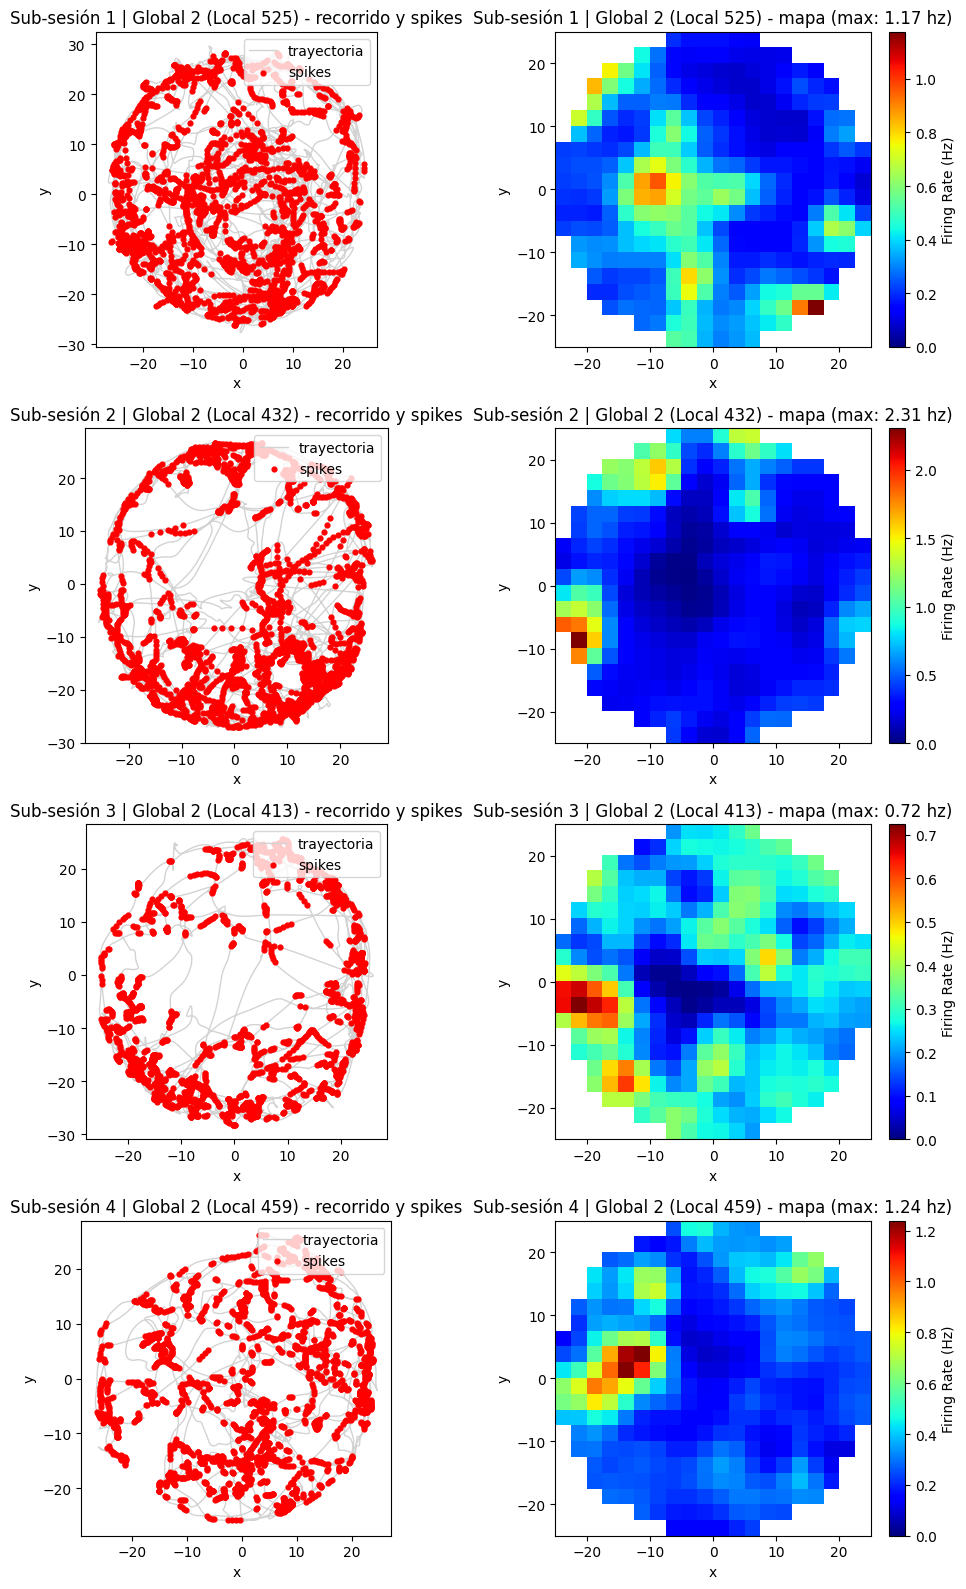

In [3]:
# 2. Graficar evolución a lo largo de las sub-sesiones
if len(common_neurons) > 0:
    fig, axes = plt.subplots(n_subs, 2, figsize=(10, 4 * n_subs))
    
    for i, sub in enumerate(subsessions):
        ax_traj = axes[i, 0]
        ax_map = axes[i, 1]
        
        local_id = local_ids[i]
        x, y, v, t = sub['x'], sub['y'], sub['v'], sub['t']
        spikes = sub['S'][:, local_id]
        
        # Calcular Place Field
        rate_map, x_bins, y_bins = compute_rate_map(
            x, y, t, spikes,
            bin_size=2.5,
            sigma=2.5,
        )
        extent = [x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]]
        
        # Graficar
        im = draw_neuron_analysis(
            ax_traj, ax_map, x, y, spikes, rate_map, extent, 
            neuron_id=f"Global {global_id} (Local {local_id})"
        )
        
        # Ajustar los títulos para indicar la sub-sesión
        ax_traj.set_title(f"Sub-sesión {i+1} | {ax_traj.get_title()}")
        ax_map.set_title(f"Sub-sesión {i+1} | {ax_map.get_title()}")
        
        # Colorbar para cada fila
        cbar = fig.colorbar(im, ax=ax_map, fraction=0.046, pad=0.04)
        cbar.set_label("Firing Rate (Hz)")

    plt.tight_layout()
    plt.show()